### create map from fit parameters


In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os
import pyfmreader as pyfm
import pyfmreader.ps_nex.parseTDMS as tdms
import numpy as np
import pyfmreader.ps_nex.loadpsnexMaps as maps
import glob
svg_dir = '/Users/evillz/Data/map_reads/take2'
import time

In [2]:

map_paths = [
    '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample3/calibration_glass/psnex_map___2026.04.23_18.23.29.37',
    '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_15_thp1/psnex_map___2026.04.15_14.45.59.91',
    # '/Users/evillz/Data/CTC44/2025_12_03/psnex_map___2025.03.12_18.38.42.45',
    '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_17/psnex_map___2026.04.17_14.20.47.21',
    '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_22/psnex_map___2026.04.22_14.51.03.45',
    '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_22/sample_2/psnex_map___2026.04.22_17.19.25.60',
    '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_22/sample_2/psnex_map___2026.04.22_17.41.42.48',
    '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_22/sample_2/psnex_map___2026.04.22_17.57.03.82',
    '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49',
    '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample2/psnex_map___2026.04.23_17.11.50.57'
    ]

In [3]:
# map_paths = [
#     '/Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample1/maps/psnex_map___2026.04.23_15.39.46.49',



# ]

<pyfmreader.utils.forcecurve.ForceCurve object at 0x1062d6940><pyfmreader.utils.forcecurve.ForceCurve object at 0x3185a6610>

<pyfmreader.utils.forcecurve.ForceCurve object at 0x317964340><pyfmreader.utils.forcecurve.ForceCurve object at 0x31797e9a0>

Saved df_point_log.csv in /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_23/sample3/calibration_glass/psnex_map___2026.04.23_18.23.29.37/results
Time taken: 9.55s
Using provided DataFrame for heatmap
Map dimensions: 64 x 64
967 Mismatched indices: [ 34  60 109 116 123 128 152 159 160 173]
Shape of x_pos_1d: (4096,)
Shape of y_pos_1d: (4096,)
Map indices were regenerated due to integrity error
zmax: 20.077884, zmin: 0.0
y_sens_um: 8.739, x_sens_um: 11.456
Saved PNG to: /Users/evillz/Data/map_reads/take2/psnex_map___2026.04.23_18.23.29.37.png
<pyfmreader.utils.forcecurve.ForceCurve object at 0x3101c1e80><pyfmreader.utils.forcecurve.ForceCurve object at 0x317d391c0>

Saved df_point_log.csv in /Volumes/SSK_Drive/2026_map_ctc44_3d/2026_04_15_thp

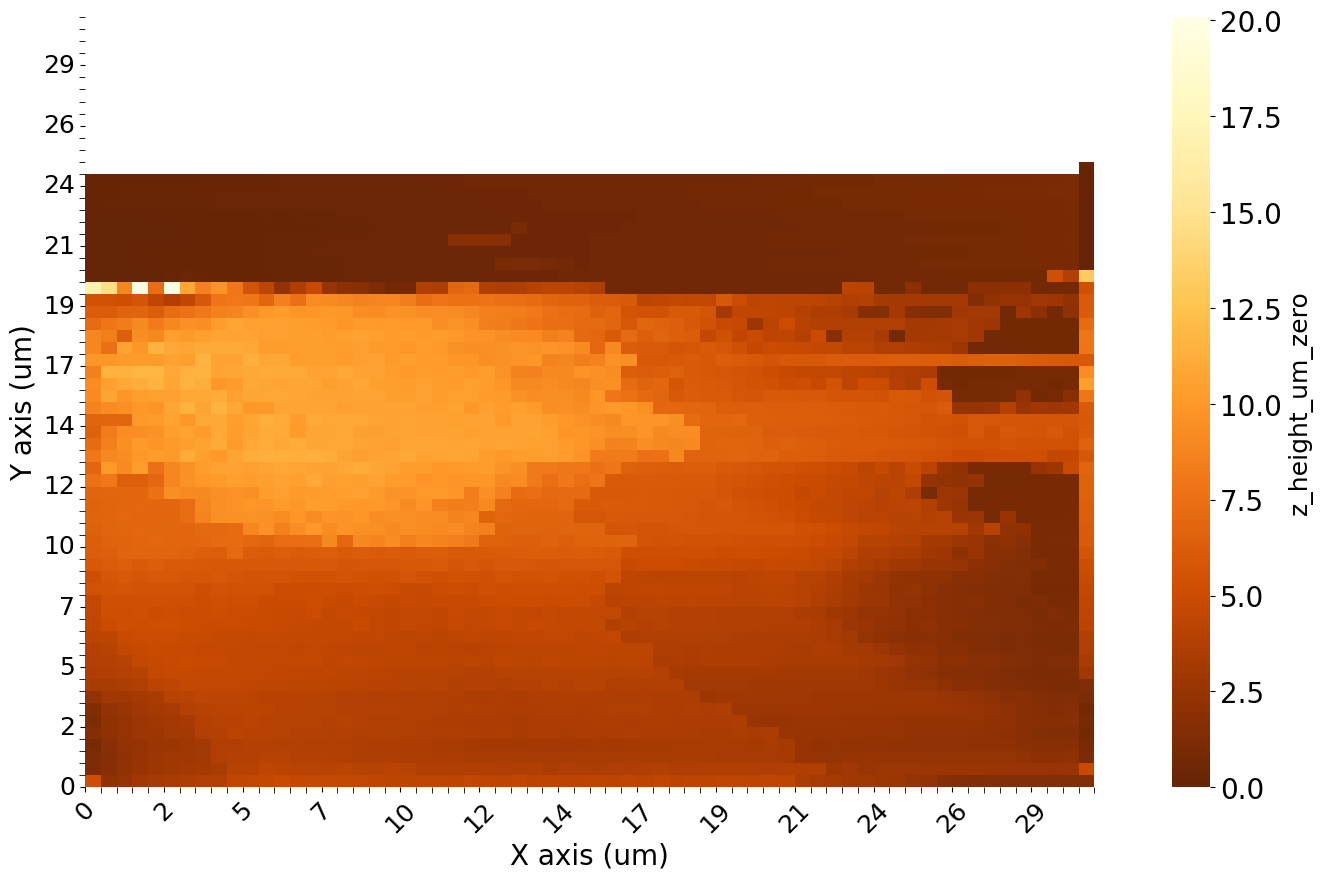

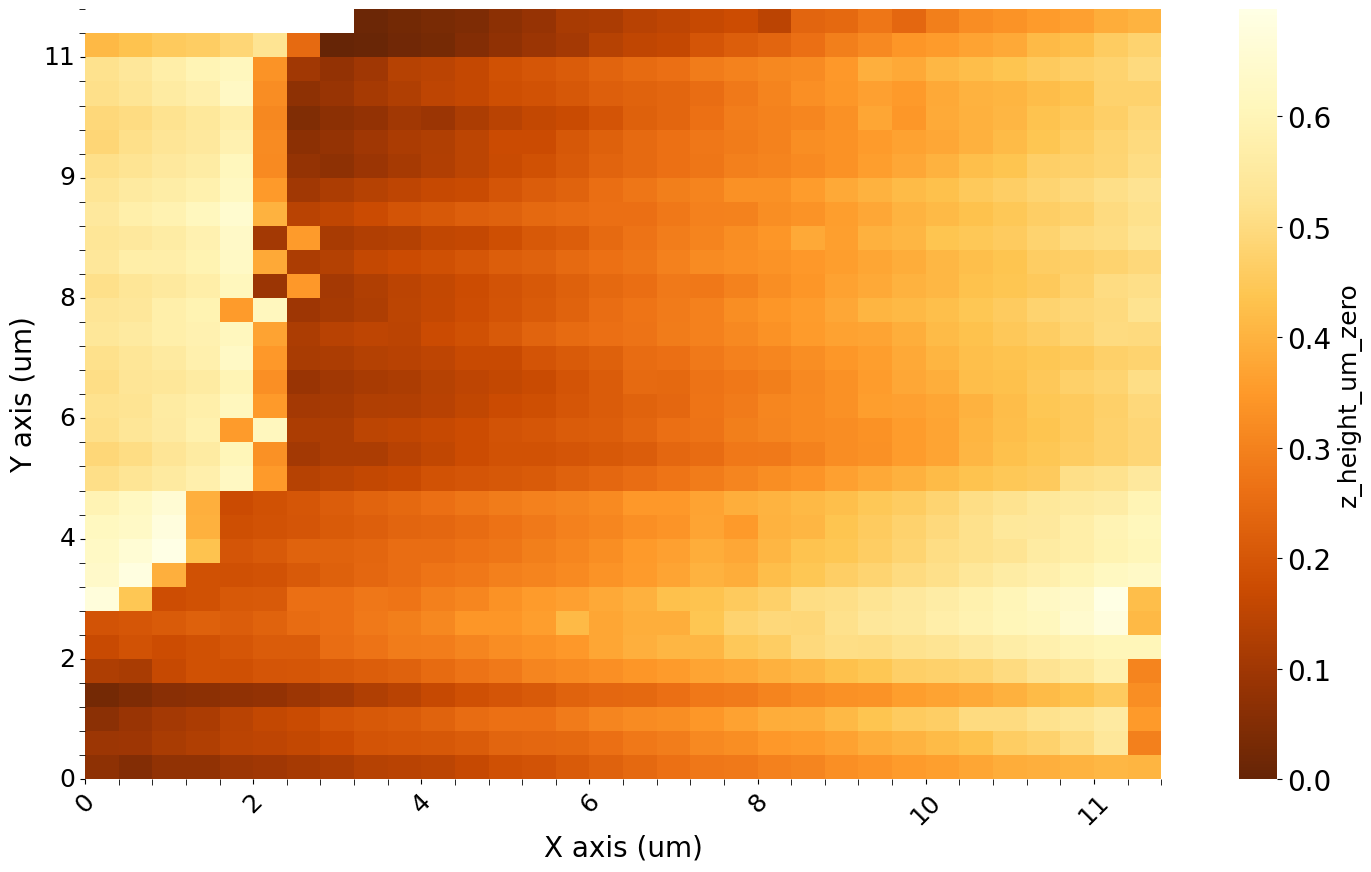

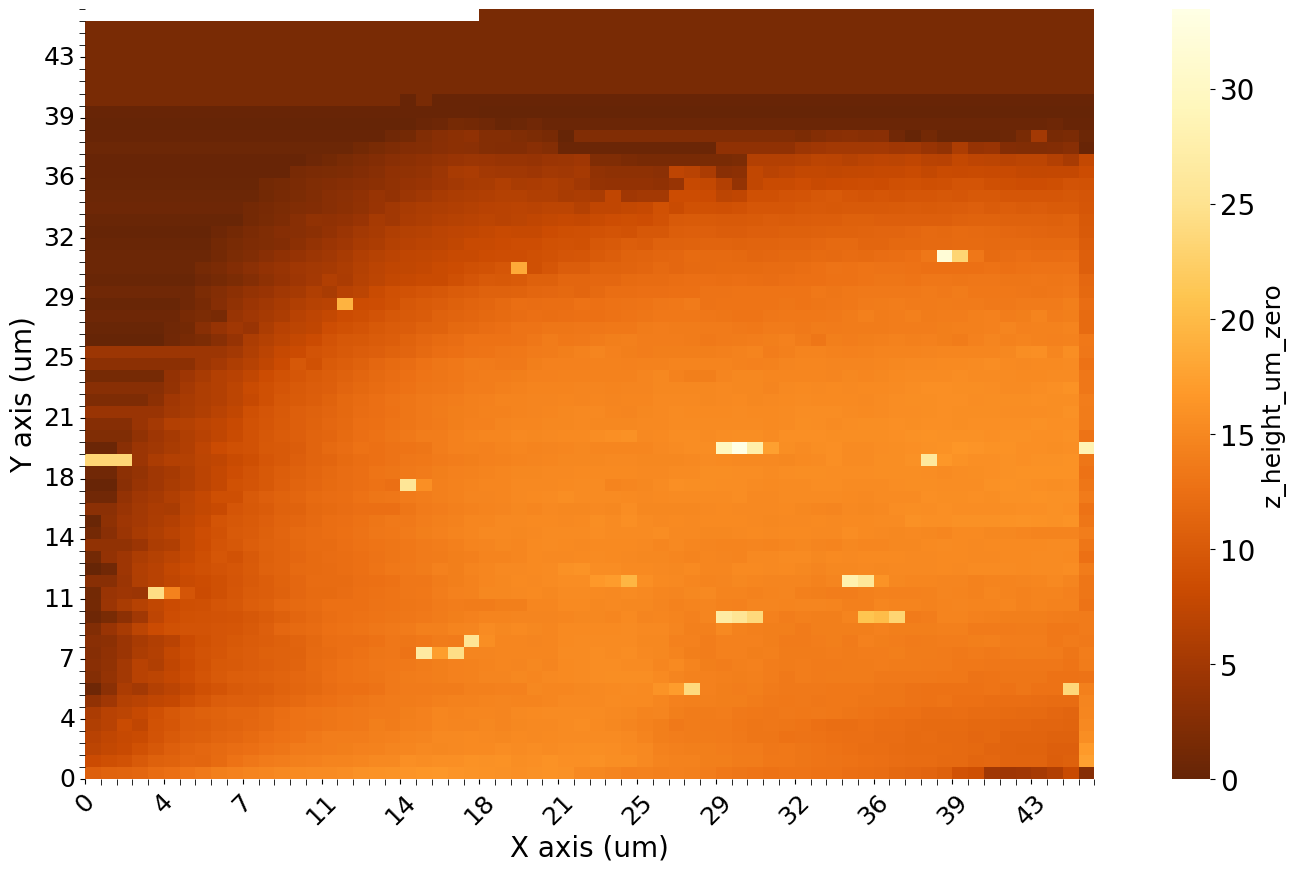

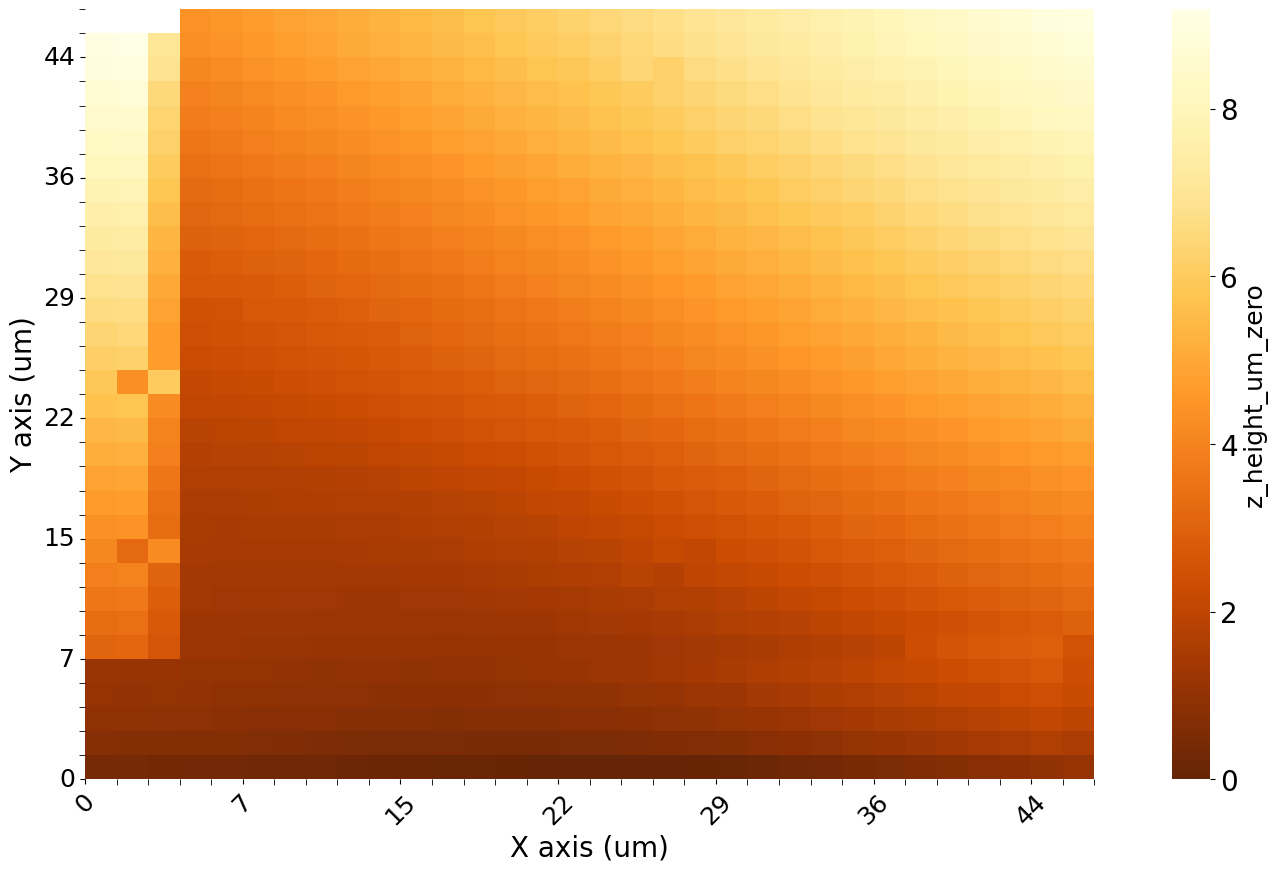

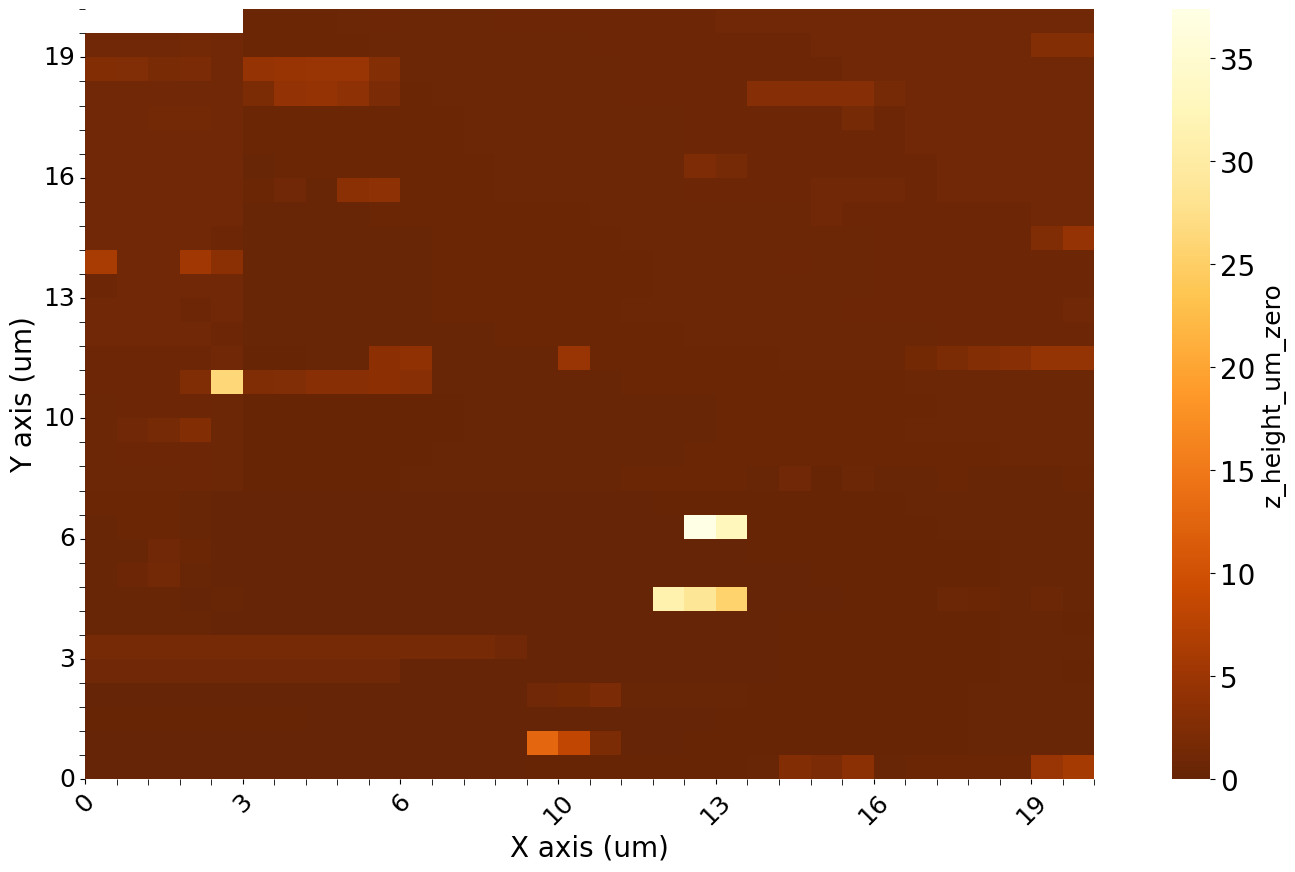

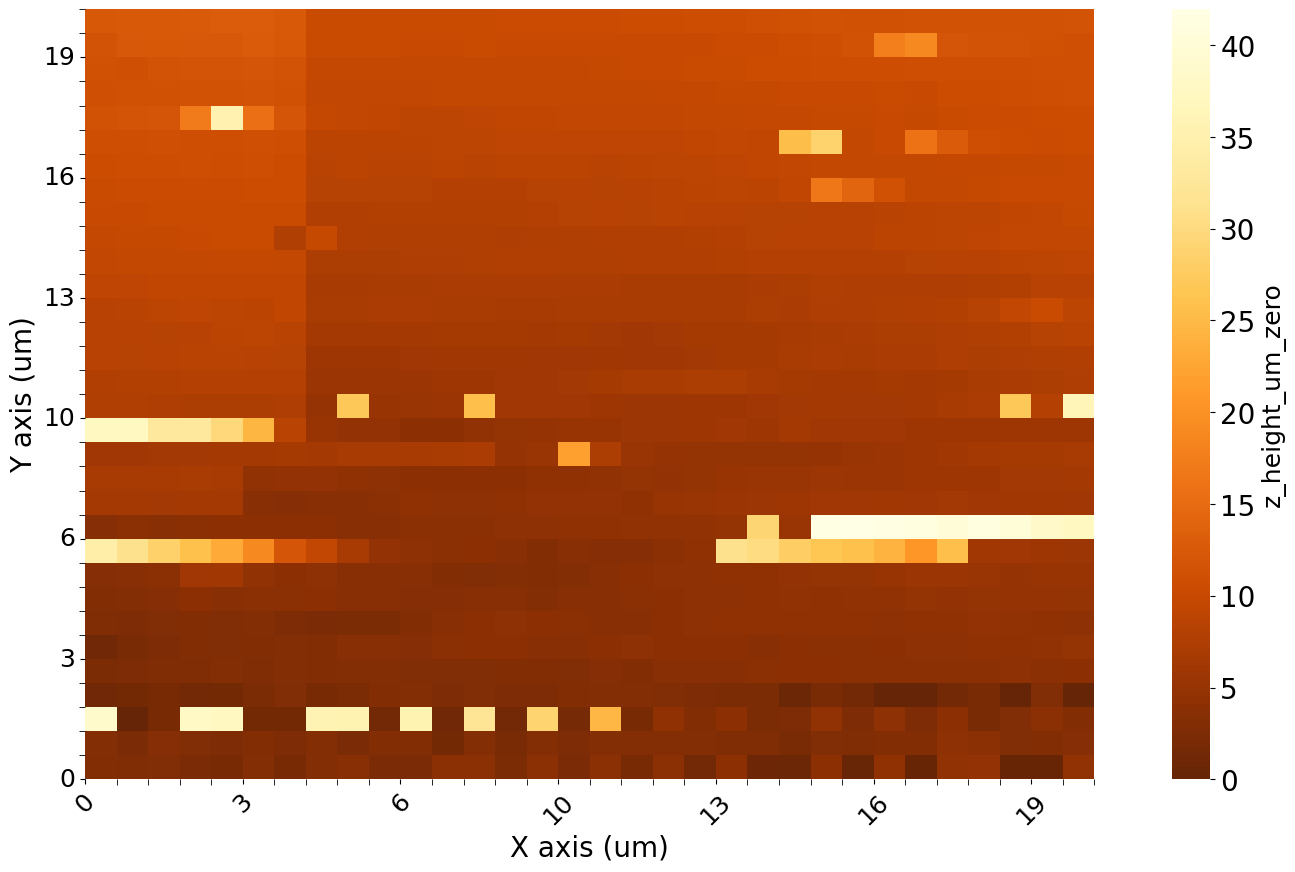

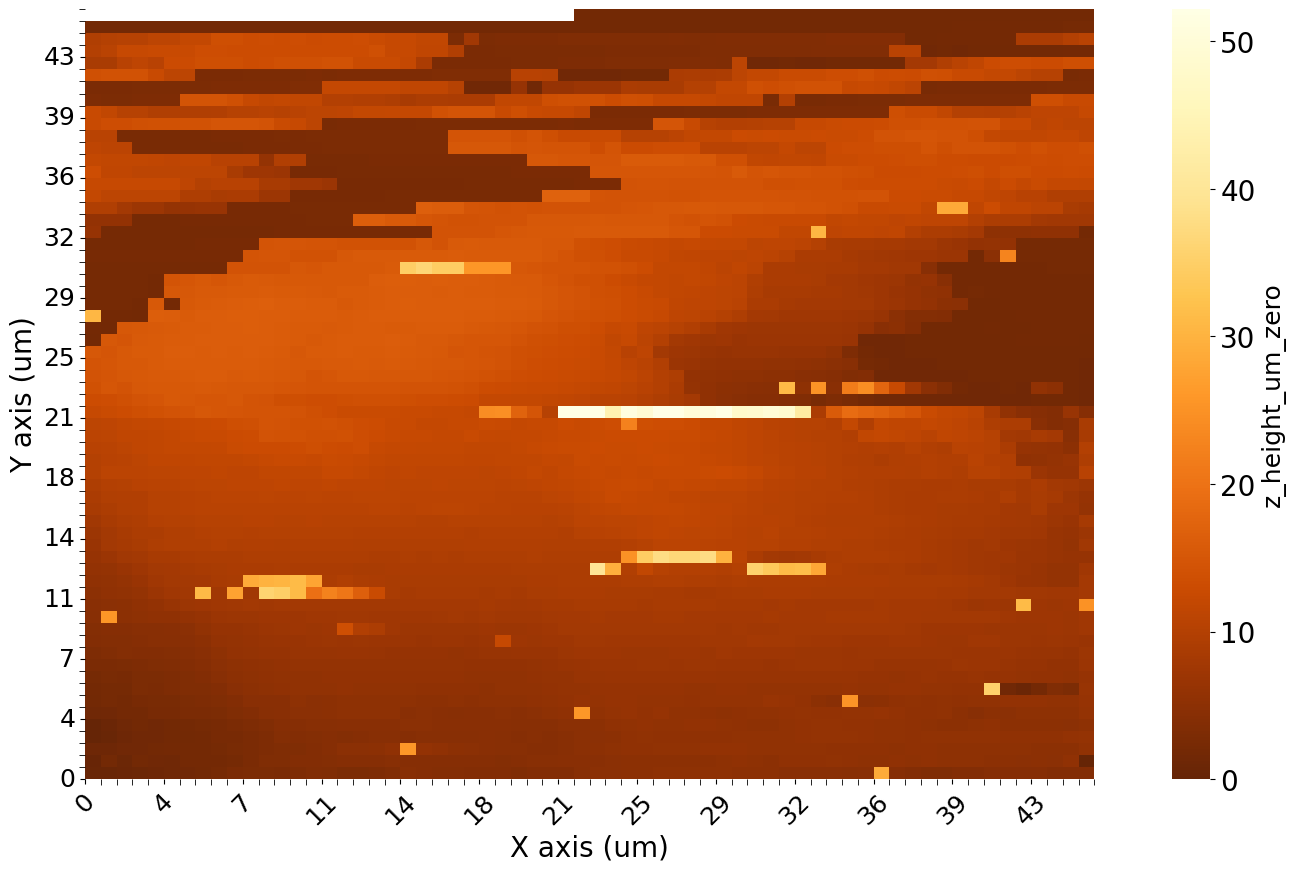

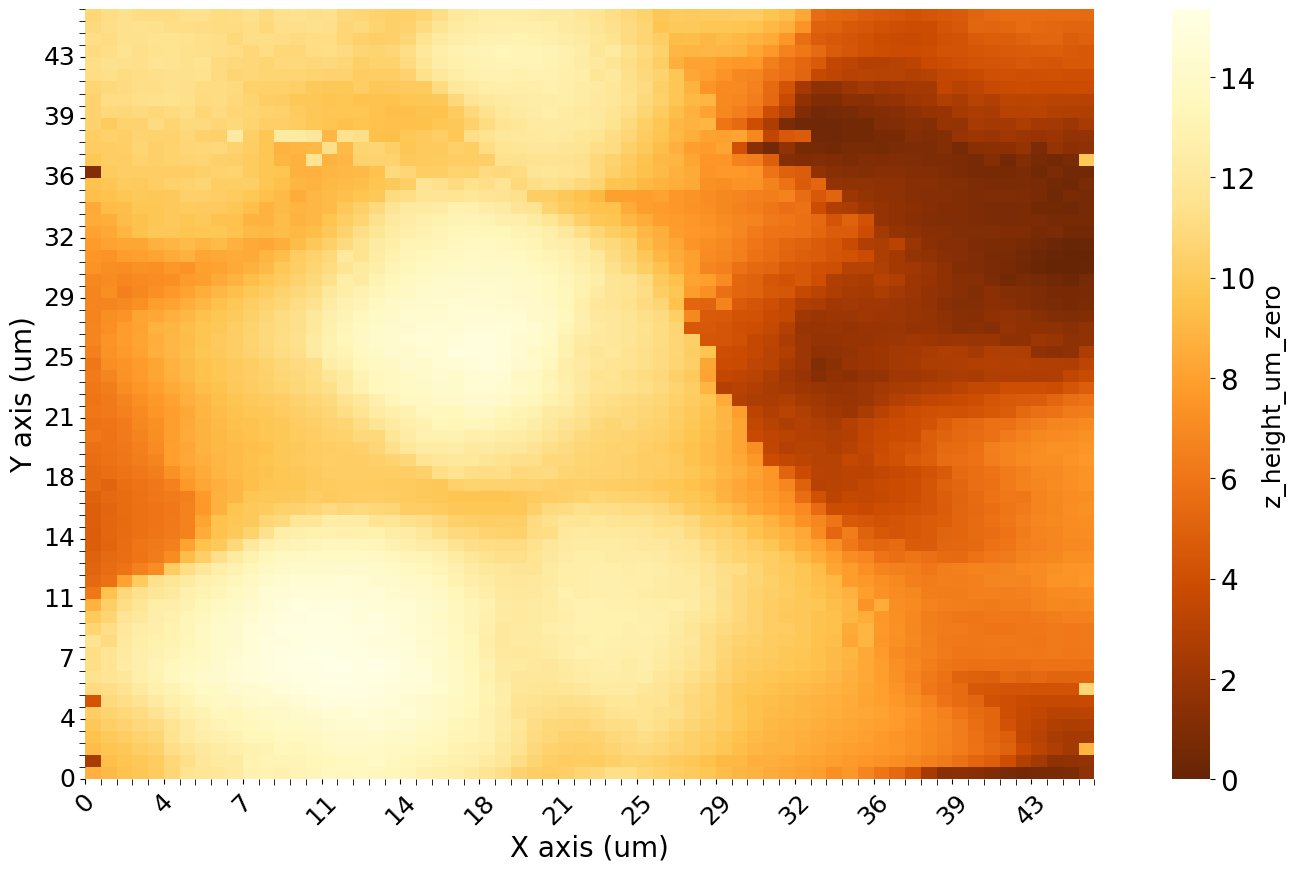

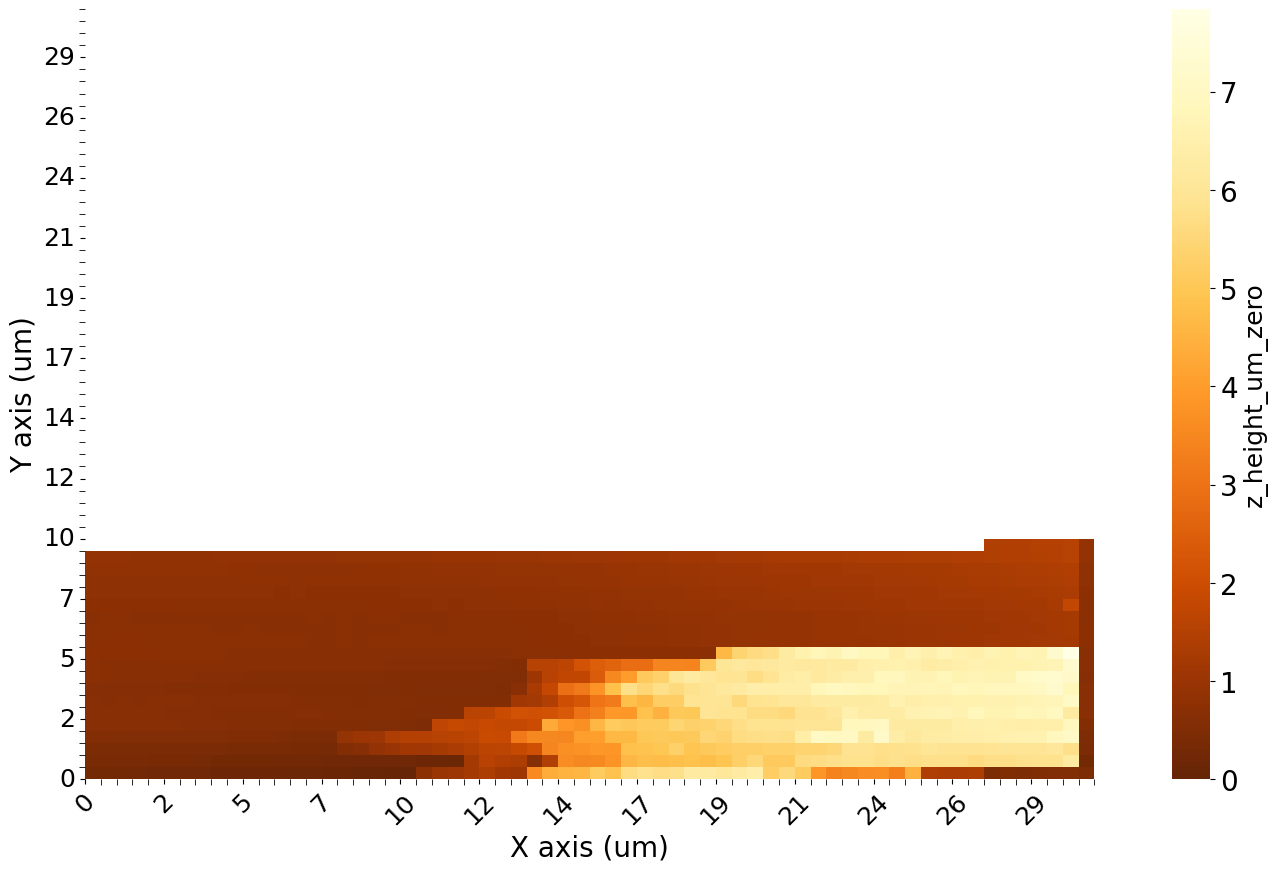

In [11]:
format = 'png'
save_fig = True
all_maps = []  # accumulate for histogram

for map_path in map_paths[:]:
    start_time = time.time()
    df_map, params, df_point_log = maps.open_and_load_map(
        map_path, CSVfile=True, estimate_xy=False, n_workers=8
    )
    end_time = time.time()
    print(f"Time taken: {end_time - start_time:.2f}s")

    map_name = os.path.basename(map_path)
    df_map['map_name'] = map_name          # label for grouping

    all_maps.append(df_map)

    svg_path = os.path.join(svg_dir, f"{map_name}.{format}")
    _ = maps.create_heatmap(
        df_map, correct_indices=True, lastColFirst=False,
        value_key="z_height_um_zero", annot=False, params=params,
        scale_axis=True, flipAxis=True, save_svg=save_fig,
        svg_path=svg_path, save_format=format, nan=True, cmap="YlOrBr"
    )
    if save_fig:
        plt.savefig(svg_path, format=format)

dft = pd.concat(all_maps, ignore_index=True)

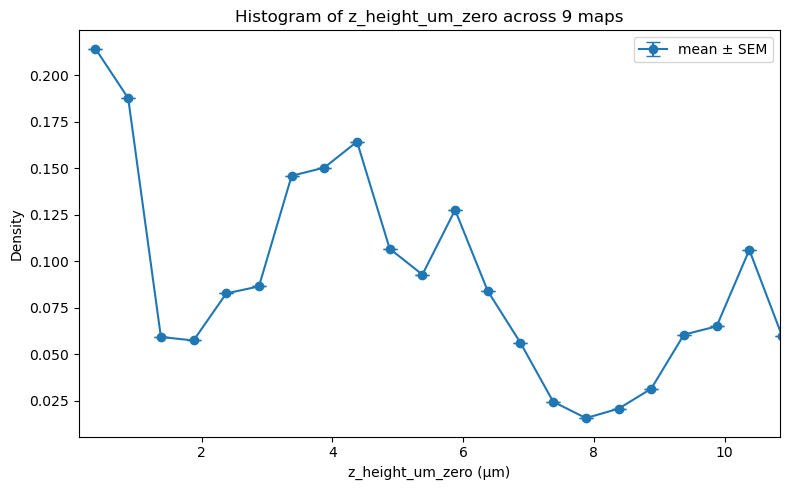

In [5]:
value_key = 'z_height_um_zero'   # column to histogram
z_min = dft[value_key].quantile(0.02)
z_max = dft[value_key].quantile(0.98)
bin_width = 0.5   # µm
bins = np.arange(z_min, z_max + bin_width, bin_width)
norm = True

colors = plt.cm.tab10(np.linspace(0, 1, len(map_paths)))
color_dict = {os.path.basename(p): c for p, c in zip(map_paths, colors)}

fig, ax = plt.subplots(figsize=(8, 5))
hist_list = []

for map_name, df_f in dft.groupby('map_name'):
    data = df_f[value_key].dropna()
    counts, _ = np.histogram(data, bins=bins, density=norm)
    hist_list.append(counts)

hist_arr    = np.array(hist_list)
mean_counts = hist_arr.mean(axis=0)
std_counts  = hist_arr.std(axis=0)
sem_counts  = std_counts / np.sqrt(len(hist_arr))
bin_centers = 0.5 * (bins[:-1] + bins[1:])

ax.errorbar(bin_centers, mean_counts, yerr=sem_counts,
            fmt='o-', capsize=5, label='mean ± SEM')
ax.fill_between(bin_centers, mean_counts - sem_counts,
                mean_counts + sem_counts, alpha=0.3)
ax.set_xlabel(f'{value_key} (µm)')
ax.set_ylabel('Density' if norm else 'Counts')
ax.set_title(f'Histogram of {value_key} across {len(map_paths)} maps')
ax.set_xlim(z_min, z_max)
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
dft_filtered = dft[dft['z_height_um_zero'] >= 1].copy()
print(f"Rows before filter: {len(dft)}, after filter: {len(dft_filtered)}")
dft_filtered['z_height_um_zero'].describe()

Rows before filter: 4096, after filter: 2579


count    2579.000000
mean        5.587251
std         2.822406
min         1.000308
25%         3.519195
50%         4.880496
75%         7.087098
max        20.077884
Name: z_height_um_zero, dtype: float64

In [7]:
print(dft['z_height_um_zero'].describe())
print(dft['z_height_um_zero'].quantile([0.90, 0.95, 0.98, 0.99, 1.0]))

count    3265.000000
mean        4.524766
std         3.248533
min         0.000000
25%         1.722474
50%         4.146972
75%         6.281802
max        20.077884
Name: z_height_um_zero, dtype: float64
0.90     9.994192
0.95    10.536806
0.98    10.847580
0.99    11.117585
1.00    20.077884
Name: z_height_um_zero, dtype: float64


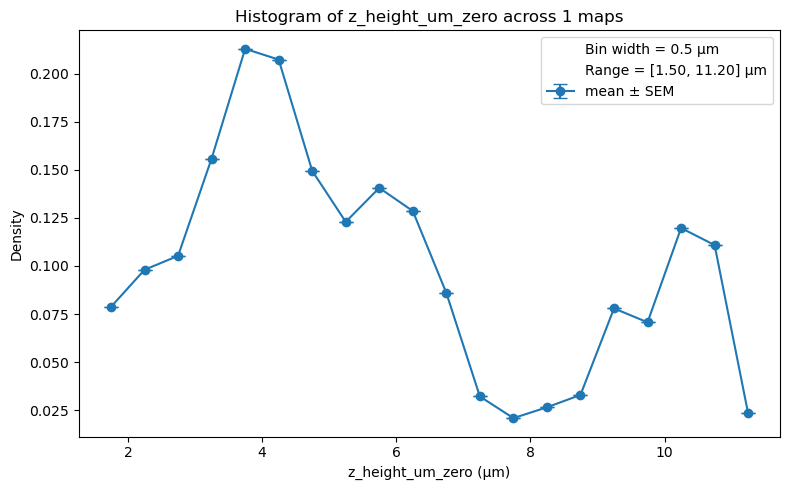

In [10]:
value_key = 'z_height_um_zero'   # column to histogram
z_min = dft_filtered[value_key].quantile(0.03)
z_max = dft_filtered[value_key].quantile(0.99)
bin_width = 0.5   # µm
bins = np.arange(z_min, z_max + bin_width, bin_width)
norm = True

colors = plt.cm.tab10(np.linspace(0, 1, len(map_paths)))
color_dict = {os.path.basename(p): c for p, c in zip(map_paths, colors)}

fig, ax = plt.subplots(figsize=(8, 5))
hist_list = []

for map_name, df_f in dft_filtered.groupby('map_name'):
    data = df_f[value_key].dropna()
    if len(data) == 0:
        continue
    counts, _ = np.histogram(data, bins=bins, density=norm)
    hist_list.append(counts)

hist_arr    = np.array(hist_list)
mean_counts = hist_arr.mean(axis=0)
std_counts  = hist_arr.std(axis=0)
sem_counts  = std_counts / np.sqrt(len(hist_arr))
bin_centers = 0.5 * (bins[:-1] + bins[1:])

ax.errorbar(
    bin_centers, mean_counts, yerr=sem_counts,
    fmt='o-', capsize=5, label='mean ± SEM'
)
ax.fill_between(
    bin_centers, mean_counts - sem_counts,
    mean_counts + sem_counts, alpha=0.3
)

# # Quartiles from filtered data
# q1, q2, q3 = dft_filtered[value_key].dropna().quantile([0.25, 0.50, 0.75])
# ax.axvline(q1, ls='--', lw=1.5, color='tab:green', label=f'Q1 = {q1:.2f} µm')
# ax.axvline(q2, ls='--', lw=1.5, color='tab:red',   label=f'Median = {q2:.2f} µm')
# ax.axvline(q3, ls='--', lw=1.5, color='tab:purple',label=f'Q3 = {q3:.2f} µm')

# Bin info in legend (dummy handle)
ax.plot([], [], ' ', label=f'Bin width = {bin_width} µm')
ax.plot([], [], ' ', label=f'Range = [{z_min:.2f}, {z_max:.2f}] µm')

ax.set_xlabel(f'{value_key} (µm)')
ax.set_ylabel('Density' if norm else 'Counts')
ax.set_title(f'Histogram of {value_key} across {len(hist_arr)} maps')
ax.legend(loc='best', frameon=True)
plt.tight_layout()
plt.show()

# describe the process of building histogram:

1. **Load map datasets**
    - A list of `map_paths` is defined for all measurements.
    - Each map is loaded with `maps.open_and_load_map(..., CSVfile=True, estimate_xy=False, n_workers=8)`.
    - For traceability, a `map_name` column is added from the folder name.

2. **Generate per-map heatmaps**
    - For each loaded `df_map`, a heatmap is created using `maps.create_heatmap(...)` with `value_key="z_height_um_zero"`.
    - Figures are saved to `svg_dir` in PNG format.

3. **Merge all maps into one table**
    - All individual map DataFrames are appended to `all_maps`.
    - They are concatenated into a single DataFrame `dft` using `pd.concat(..., ignore_index=True)`.

4. **Define histogram range and bins**
    - The analyzed variable is `value_key = "z_height_um_zero"`.
    - Robust limits are set with quantiles (`z_min = 2%`, `z_max = 98%`) to reduce outlier influence.
    - Bin edges are built with fixed width (`bin_width = 0.5 µm`).
    - Histograms are normalized (`density=True`) for cross-map comparison.

5. **Compute per-map histograms**
    - Data is grouped by `map_name`.
    - For each map, NaNs are removed and `np.histogram(..., density=True)` is computed.
    - Results are stored in `hist_list`, then converted to `hist_arr`.

6. **Aggregate across maps**
    - Mean profile: `mean_counts = hist_arr.mean(axis=0)`
    - Variability: `std_counts = hist_arr.std(axis=0)`
    - Uncertainty: `sem_counts = std_counts / sqrt(n_maps)`
    - Bin centers are computed for plotting.

7. **Plot summary histogram**
    - `mean_counts` is shown with error bars (`± SEM`) using `ax.errorbar`.
    - A shaded confidence band is added with `ax.fill_between`.
    - Axes, title, and limits are set for clear interpretation.

8. **Optional filtering step**
    - A filtered dataset (`dft_filtered = dft[dft["z_height_um_zero"] >= 1]`) is created.
    - The same histogram pipeline is repeated to focus on biologically/physically relevant heights.
